# SoftCom myopia-risk benchmark - Section 4 - Explainable AI

Replication and extension of Mu et al. 2024 (Front. Med. 11:1482788) on the provided **hybrid cohort (N=1500)**. Pipeline validation only - no clinical claims.

**Pipeline:** SoftCom_01_Data_Validation -> SoftCom_02_Preprocessing -> SoftCom_03_Benchmarking -> **SoftCom_04_Explainable_AI** -> SoftCom_05_Figures -> SoftCom_06_Export

All inputs and outputs live in Google Drive at `MyDrive/SoftCom_Myopia/`. Each notebook checks `artifacts/manifest.json` and stops if an upstream step has not run or its files have changed.

| | |
|---|---|
| **Reads** | outputs of 02 and 03 (fitted models) |
| **Writes** | `figures/fig3_or_forest`, `fig6_importance`, `fig7_shap_*`, `tables/table4-6`, `artifacts/xai_meta.json` |
| **Next** | `SoftCom_05_Figures.ipynb` |

Runtime: Colab CPU is enough. Use *Runtime -> Run all*; accept the Drive prompt in the setup cell. For a quick trial run, set `"FAST_MODE": True` in the CONFIG cell of **every** notebook (fewer CV repeats/bootstraps); set it back to `False` for the reported results.

## 0. Install dependencies and set up Google Drive

In [1]:
%pip install -q "shap>=0.47" xgboost lightgbm statsmodels imbalanced-learn

In [2]:
"""Shared setup (identical in every SoftCom notebook).

Mounts Google Drive, defines CONFIG, the Drive folder layout, the run manifest
that links the six notebooks together, seeding, logging and figure helpers.
"""
from __future__ import annotations

import hashlib
import json
import os
import random
import shutil
import sys
import time
import warnings
from datetime import datetime, timezone
from pathlib import Path
from typing import Any, Callable, Dict, Iterable, List, Optional, Sequence, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)

# ----------------------------------------------------------------------------- CONFIG
CONFIG: Dict[str, Any] = {
    "SEED": 42,
    "TEST_SIZE": 0.3,
    "N_SPLITS": 5,
    "N_REPEATS": 10,
    "N_BOOTSTRAP": 2000,
    "EXPECTED_N_ROWS": 1500,
    "DATA_FILENAME": "full_myopia_hybrid_dataset_N1500.csv",
    "PILOT_FILENAME": "pilot_real.csv",          # optional 73-row pilot; never merged
    "TARGET": "is_myopic",
    "SOURCE_LABEL": "hybrid",
    "COHORT_LABEL": "Hybrid cohort (N=1500) - pipeline validation only, not clinical evidence",
    "DRIVE_PROJECT_DIR": "SoftCom_Myopia",       # folder inside MyDrive holding everything
    "USE_SMOTE": False,                          # SMOTE inside pipeline only (imblearn)
    "USE_LASSO_SELECTION": True,                 # L1-logistic SelectFromModel inside pipeline
    "ABLATION": True,                            # also run FT-Transformer without attention
    "DEEP_MAX_EPOCHS": 200,
    "DEEP_PATIENCE": 20,
    "DEEP_BATCH_SIZE": 64,
    "PERM_N_REPEATS": 20,
    "SHAP_BACKGROUND": 100,
    "SHAP_N_EXPLAIN": 150,
    "SHAP_KERNEL_NSAMPLES": 200,
    "FAST_MODE": False,                          # True = quick trial run (same value in all notebooks)
}
CONFIG["FAST_MODE"] |= os.environ.get("SOFTCOM_FAST", "0") == "1"  # local smoke tests
if CONFIG["FAST_MODE"]:
    CONFIG.update(N_REPEATS=2, N_BOOTSTRAP=200, DEEP_MAX_EPOCHS=25, DEEP_PATIENCE=5,
                  PERM_N_REPEATS=3, SHAP_BACKGROUND=20, SHAP_N_EXPLAIN=20,
                  SHAP_KERNEL_NSAMPLES=60)
SEED: int = CONFIG["SEED"]

NOTEBOOKS: Dict[str, str] = {
    "01_data": "SoftCom_01_Data_Validation.ipynb",
    "02_preprocessing": "SoftCom_02_Preprocessing.ipynb",
    "03_benchmark": "SoftCom_03_Benchmarking.ipynb",
    "04_xai": "SoftCom_04_Explainable_AI.ipynb",
    "05_figures": "SoftCom_05_Figures.ipynb",
    "06_export": "SoftCom_06_Export.ipynb",
}

# ----------------------------------------------------------------------------- Drive
LAUNCH_DIR: Path = Path.cwd()
try:
    from google.colab import drive  # type: ignore

    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    if not Path("/content/drive/MyDrive").is_dir():
        try:
            drive.mount("/content/drive")
        except Exception as exc:  # pragma: no cover - interactive auth
            raise RuntimeError(
                "Google Drive mount failed. Re-run this cell and accept the Drive "
                f"authorisation prompt. Original error: {exc}"
            ) from exc
    PROJECT_ROOT = Path("/content/drive/MyDrive") / CONFIG["DRIVE_PROJECT_DIR"]
else:
    PROJECT_ROOT = Path(os.environ.get("SOFTCOM_ROOT", LAUNCH_DIR / CONFIG["DRIVE_PROJECT_DIR"])).resolve()

DIRS: Dict[str, Path] = {
    name: PROJECT_ROOT / sub
    for name, sub in {
        "raw": "data/raw",
        "processed": "data/processed",
        "models": "models",
        "predictions": "predictions",
        "tables": "tables",
        "figures": "figures",
        "artifacts": "artifacts",
        "logs": "logs",
    }.items()
}
for _d in DIRS.values():
    _d.mkdir(parents=True, exist_ok=True)
os.chdir(PROJECT_ROOT)  # so ./figures/ and ./tables/ resolve inside Google Drive
MANIFEST_PATH: Path = DIRS["artifacts"] / "manifest.json"


# ----------------------------------------------------------------------------- helpers
def set_global_seed(seed: int = SEED) -> None:
    """Seed python, numpy and (if installed) torch for reproducible runs."""
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    try:
        import torch  # type: ignore

        torch.manual_seed(seed)
        torch.use_deterministic_algorithms(True, warn_only=True)
    except ImportError:
        pass


def log(step: str, message: str) -> None:
    """Print a message and append it to logs/<step>.log on Drive."""
    stamp = datetime.now(timezone.utc).strftime("%Y-%m-%d %H:%M:%S")
    print(message)
    with open(DIRS["logs"] / f"{step}.log", "a", encoding="utf-8") as fh:
        fh.write(f"[{stamp}] {message}\n")


def sha256_file(path: Path) -> str:
    """Return the SHA-256 hex digest of a file."""
    h = hashlib.sha256()
    with open(path, "rb") as fh:
        for chunk in iter(lambda: fh.read(1 << 20), b""):
            h.update(chunk)
    return h.hexdigest()


def rel(path: Path) -> str:
    """Path relative to the project root (as stored in the manifest)."""
    return str(Path(path).resolve().relative_to(PROJECT_ROOT))


def _atomic_write_json(obj: Any, path: Path) -> None:
    tmp = path.with_suffix(path.suffix + ".tmp")
    with open(tmp, "w", encoding="utf-8") as fh:
        json.dump(obj, fh, indent=2, default=str)
    os.replace(tmp, path)


def save_json(obj: Any, path: Path) -> Path:
    """Write JSON atomically (numpy/pandas values are stringified if needed)."""
    _atomic_write_json(obj, path)
    return path


def load_manifest() -> Dict[str, Any]:
    """Load the cross-notebook run manifest (empty skeleton if absent)."""
    if MANIFEST_PATH.exists():
        with open(MANIFEST_PATH, encoding="utf-8") as fh:
            return json.load(fh)
    return {"project": "SoftCom myopia benchmark", "steps": {}}


def register_outputs(step: str, paths: Iterable[Path], extra: Optional[Dict[str, Any]] = None) -> None:
    """Record a finished notebook step and the SHA-256 of every file it wrote."""
    manifest = load_manifest()
    files = {}
    for p in paths:
        p = Path(p)
        if not p.exists():
            raise FileNotFoundError(f"[{step}] expected output was not written: {p}")
        files[rel(p)] = sha256_file(p)
    manifest["steps"][step] = {
        "notebook": NOTEBOOKS[step],
        "status": "ok",
        "finished_at": datetime.now(timezone.utc).isoformat(timespec="seconds"),
        "fast_mode": CONFIG["FAST_MODE"],
        "outputs": files,
        "extra": extra or {},
    }
    _atomic_write_json(manifest, MANIFEST_PATH)
    print(f"Manifest updated: step '{step}' -> {len(files)} files registered.")


def require_upstream(step: str, needed: Sequence[str]) -> None:
    """Fail loudly unless `step` ran successfully and its files are unchanged.

    `needed` are project-relative paths that this notebook will read.
    """
    manifest = load_manifest()
    info = manifest["steps"].get(step)
    if info is None or info.get("status") != "ok":
        raise RuntimeError(
            f"Upstream step '{step}' has not completed. Open and 'Run all' "
            f"{NOTEBOOKS[step]} first (results folder: {PROJECT_ROOT})."
        )
    for r in needed:
        p = PROJECT_ROOT / r
        if not p.exists():
            raise FileNotFoundError(f"Missing upstream file {r}; re-run {NOTEBOOKS[step]}.")
        expected = info["outputs"].get(r)
        if expected is None:
            raise RuntimeError(f"{r} is not registered by {NOTEBOOKS[step]}; re-run it.")
        if sha256_file(p) != expected:
            raise RuntimeError(
                f"{r} changed after {NOTEBOOKS[step]} finished (hash drift). "
                f"Re-run {NOTEBOOKS[step]} and the notebooks after it."
            )
    if info.get("fast_mode") != CONFIG["FAST_MODE"]:
        print(f"WARNING: {step} ran with FAST_MODE={info.get('fast_mode')}, this notebook uses "
              f"FAST_MODE={CONFIG['FAST_MODE']}.")
    print(f"Upstream OK: {step} ({info['finished_at']}), {len(needed)} files verified.")


sns.set_theme(style="whitegrid", context="notebook", font_scale=1.1)
plt.rcParams.update({"font.size": 11, "axes.titlesize": 12, "axes.labelsize": 11,
                     "legend.fontsize": 10, "savefig.bbox": "tight"})


def save_figure(fig: plt.Figure, name: str, footnote: bool = True) -> List[Path]:
    """Save `fig` as 300-DPI PNG and SVG in ./figures/ (on Drive) and close it."""
    if footnote:  # place below everything already drawn (rotated tick labels included)
        bottom = fig.get_tightbbox(fig.canvas.get_renderer()).y0 / fig.get_figheight()
        fig.text(0.995, min(bottom, 0.0) - 0.01, CONFIG["COHORT_LABEL"], ha="right", va="top", fontsize=8, color="0.45")
    out = []
    try:
        for ext in ("png", "svg"):
            p = DIRS["figures"] / f"{name}.{ext}"
            fig.savefig(p, dpi=300, bbox_inches="tight")
            out.append(p)
    except OSError as exc:
        raise RuntimeError(f"Could not write figure {name} to {DIRS['figures']}: {exc}") from exc
    finally:
        plt.close(fig)
    print(f"Saved figure: figures/{name}.png + .svg")
    return out


def show_saved(name: str) -> None:
    """Display a saved PNG inline (Colab/Jupyter only)."""
    try:
        from IPython.display import Image, display  # type: ignore

        if "ipykernel" in sys.modules:
            display(Image(filename=str(DIRS["figures"] / f"{name}.png"), width=720))
    except ImportError:
        pass


set_global_seed(SEED)
print(f"Colab: {IN_COLAB} | results folder: {PROJECT_ROOT} | FAST_MODE={CONFIG['FAST_MODE']}")

Mounted at /content/drive
Colab: True | results folder: /content/drive/MyDrive/SoftCom_Myopia | FAST_MODE=False


In [3]:
"""Model library: pipeline builder, MODEL_REGISTRY, PyTorch tabular models, metrics, DeLong.

Identical in notebooks 03 and 04 so fitted models saved by 03 can be unpickled by 04.
"""
import copy
from dataclasses import dataclass, field
from typing import Callable, Tuple

import sklearn
from sklearn.base import BaseEstimator, ClassifierMixin, clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline as SkPipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

OPTIONAL_LIBS: Dict[str, bool] = {}
try:
    from xgboost import XGBClassifier  # type: ignore
    OPTIONAL_LIBS["xgboost"] = True
except ImportError:
    OPTIONAL_LIBS["xgboost"] = False
try:
    from lightgbm import LGBMClassifier  # type: ignore
    OPTIONAL_LIBS["lightgbm"] = True
except ImportError:
    OPTIONAL_LIBS["lightgbm"] = False
try:
    from imblearn.over_sampling import SMOTE  # type: ignore
    from imblearn.pipeline import Pipeline as ImbPipeline  # type: ignore
    OPTIONAL_LIBS["imblearn"] = True
except ImportError:
    OPTIONAL_LIBS["imblearn"] = False
try:
    import torch  # type: ignore
    from torch import nn  # type: ignore
    OPTIONAL_LIBS["torch"] = True
except ImportError:
    OPTIONAL_LIBS["torch"] = False
print("Optional libraries:", OPTIONAL_LIBS)
if CONFIG["USE_SMOTE"] and not OPTIONAL_LIBS["imblearn"]:
    raise ImportError("CONFIG['USE_SMOTE']=True needs imbalanced-learn: run the install cell.")

SKLEARN_VERSION: Tuple[int, int] = tuple(int(v) for v in sklearn.__version__.split(".")[:2])  # type: ignore


def l1_logistic(C: float = 0.5) -> LogisticRegression:
    """L1-penalised logistic regression, compatible with sklearn <1.8 and >=1.8."""
    kw: Dict[str, Any] = dict(C=C, solver="liblinear", class_weight="balanced", random_state=SEED, max_iter=2000)
    if SKLEARN_VERSION >= (1, 8):
        kw["l1_ratio"] = 1.0
    else:
        kw["penalty"] = "l1"
    return LogisticRegression(**kw)


# ----------------------------------------------------------------------------- pipeline
@dataclass
class FactoryContext:
    """Everything a model factory needs to build its pipeline."""

    numeric: List[str]
    categorical: List[str]
    cat_cardinalities: List[int]
    pos_weight: float
    seed: int = SEED


def build_preprocessor(numeric: List[str], categorical: List[str]) -> ColumnTransformer:
    """Impute+scale numeric, impute categorical codes. Output order: numeric, categorical."""
    num = SkPipeline([("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler())])
    cat = SimpleImputer(strategy="most_frequent")
    return ColumnTransformer([("num", num, numeric), ("cat", cat, categorical)],
                             verbose_feature_names_out=False)


def make_pipeline(model: Any, ctx: FactoryContext, use_selector: bool = True) -> Any:
    """imputer -> scaler -> [SMOTE] -> LASSO selector -> model, all fitted inside CV folds."""
    steps: List[Tuple[str, Any]] = [("prep", build_preprocessor(ctx.numeric, ctx.categorical))]
    if CONFIG["USE_SMOTE"]:
        steps.append(("smote", SMOTE(random_state=ctx.seed)))
    if use_selector and CONFIG["USE_LASSO_SELECTION"]:
        steps.append(("select", SelectFromModel(l1_logistic(0.5), threshold=1e-5)))
    steps.append(("model", model))
    return ImbPipeline(steps) if CONFIG["USE_SMOTE"] else SkPipeline(steps)


# ----------------------------------------------------------------------------- torch models
if OPTIONAL_LIBS["torch"]:

    class _MLPNet(nn.Module):
        """MLP with entity embeddings for categorical codes."""

        def __init__(self, n_num: int, cards: Sequence[int], hidden: int, dropout: float) -> None:
            super().__init__()
            self.embs = nn.ModuleList([nn.Embedding(c, min(4, (c + 1) // 2 + 1)) for c in cards])
            d_in = n_num + sum(e.embedding_dim for e in self.embs)
            self.body = nn.Sequential(nn.Linear(d_in, hidden), nn.ReLU(), nn.Dropout(dropout), nn.Linear(hidden, 1))

        def forward(self, x_num: "torch.Tensor", x_cat: "torch.Tensor") -> "torch.Tensor":
            parts = [x_num] + [emb(x_cat[:, i]) for i, emb in enumerate(self.embs)]
            return self.body(torch.cat(parts, dim=1)).squeeze(1)

    class _FTTNet(nn.Module):
        """Minimal FT-Transformer: feature tokenizer + [CLS] + TransformerEncoder."""

        def __init__(self, n_num: int, cards: Sequence[int], d: int, n_heads: int, n_layers: int,
                     dropout: float, use_attention: bool) -> None:
            super().__init__()
            self.num_w = nn.Parameter(torch.randn(n_num, d) * 0.1)
            self.num_b = nn.Parameter(torch.zeros(n_num, d))
            self.cat_embs = nn.ModuleList([nn.Embedding(c, d) for c in cards])
            self.cls = nn.Parameter(torch.zeros(1, 1, d))
            self.use_attention = use_attention
            if use_attention:
                layer = nn.TransformerEncoderLayer(d_model=d, nhead=n_heads, dim_feedforward=2 * d,
                                                   dropout=dropout, batch_first=True, norm_first=True)
                self.encoder = nn.TransformerEncoder(layer, num_layers=n_layers, enable_nested_tensor=False)
            else:  # ablation: same tokenizer and head, no self-attention
                self.encoder = nn.Sequential(nn.Linear(d, d), nn.ReLU(), nn.Dropout(dropout))
            self.head = nn.Sequential(nn.LayerNorm(d), nn.ReLU(), nn.Linear(d, 1))

        def forward(self, x_num: "torch.Tensor", x_cat: "torch.Tensor") -> "torch.Tensor":
            tokens = [x_num.unsqueeze(-1) * self.num_w + self.num_b]
            if len(self.cat_embs):
                tokens.append(torch.stack([emb(x_cat[:, i]) for i, emb in enumerate(self.cat_embs)], dim=1))
            t = torch.cat(tokens, dim=1)
            if self.use_attention:
                t = torch.cat([self.cls.expand(t.shape[0], -1, -1), t], dim=1)
                return self.head(self.encoder(t)[:, 0]).squeeze(1)
            return self.head(self.encoder(t).mean(dim=1)).squeeze(1)


class TorchTabularClassifier(ClassifierMixin, BaseEstimator):
    """sklearn-compatible PyTorch classifier (arch='mlp' or 'ftt').

    Expects the last `len(cat_cardinalities)` input columns to be integer category codes
    (the preprocessor output order). Early-stops on the AUC of an inner stratified
    validation split carved out of the training fold only.
    """

    def __init__(self, arch: str = "mlp", cat_cardinalities: Tuple[int, ...] = (), hidden: int = 16,
                 d_token: int = 16, n_heads: int = 2, n_layers: int = 2, dropout: float = 0.3,
                 lr: float = 1e-3, weight_decay: float = 0.01, batch_size: int = 64, max_epochs: int = 200,
                 patience: int = 20, val_fraction: float = 0.15, use_attention: bool = True,
                 balanced: bool = True, random_state: int = SEED) -> None:
        self.arch = arch
        self.cat_cardinalities = cat_cardinalities
        self.hidden = hidden
        self.d_token = d_token
        self.n_heads = n_heads
        self.n_layers = n_layers
        self.dropout = dropout
        self.lr = lr
        self.weight_decay = weight_decay
        self.batch_size = batch_size
        self.max_epochs = max_epochs
        self.patience = patience
        self.val_fraction = val_fraction
        self.use_attention = use_attention
        self.balanced = balanced
        self.random_state = random_state

    def _split(self, X: np.ndarray) -> Tuple["torch.Tensor", "torch.Tensor"]:
        n_cat = len(self.cat_cardinalities)
        n_num = X.shape[1] - n_cat
        x_num = torch.tensor(X[:, :n_num], dtype=torch.float32)
        cat = np.rint(X[:, n_num:]).astype(np.int64)
        if n_cat:
            cat = np.clip(cat, 0, np.asarray(self.cat_cardinalities) - 1)
        return x_num, torch.tensor(cat, dtype=torch.long)

    def _build(self, n_num: int) -> "nn.Module":
        if self.arch == "mlp":
            return _MLPNet(n_num, self.cat_cardinalities, self.hidden, self.dropout)
        if self.arch == "ftt":
            return _FTTNet(n_num, self.cat_cardinalities, self.d_token, self.n_heads, self.n_layers,
                           self.dropout, self.use_attention)
        raise ValueError(f"Unknown arch {self.arch!r}")

    def fit(self, X: Any, y: Any) -> "TorchTabularClassifier":
        """Train with AdamW (L2 via weight_decay) and AUC-based early stopping."""
        if not OPTIONAL_LIBS["torch"]:
            raise ImportError("PyTorch is required for TorchTabularClassifier.")
        X = np.asarray(X, dtype=np.float64)
        y = np.asarray(y).astype(int)
        self.classes_ = np.array([0, 1])
        self.n_features_in_ = X.shape[1]
        torch.manual_seed(self.random_state)
        Xtr, Xva, ytr, yva = train_test_split(X, y, test_size=self.val_fraction, stratify=y,
                                              random_state=self.random_state)
        xn_tr, xc_tr = self._split(Xtr)
        xn_va, xc_va = self._split(Xva)
        yt = torch.tensor(ytr, dtype=torch.float32)
        net = self._build(xn_tr.shape[1])
        pos_w = (len(ytr) - ytr.sum()) / max(ytr.sum(), 1) if self.balanced else 1.0
        loss_fn = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(float(pos_w)))
        opt = torch.optim.AdamW(net.parameters(), lr=self.lr, weight_decay=self.weight_decay)
        gen = torch.Generator().manual_seed(self.random_state)
        best_auc, best_state, wait = -np.inf, None, 0
        self.history_: Dict[str, List[float]] = {"train_loss": [], "val_loss": [], "val_auc": []}
        for _epoch in range(self.max_epochs):
            net.train()
            perm = torch.randperm(len(yt), generator=gen)
            losses = []
            for i in range(0, len(perm), self.batch_size):
                idx = perm[i:i + self.batch_size]
                opt.zero_grad()
                loss = loss_fn(net(xn_tr[idx], xc_tr[idx]), yt[idx])
                loss.backward()
                opt.step()
                losses.append(loss.item())
            net.eval()
            with torch.no_grad():
                logit_va = net(xn_va, xc_va)
                val_loss = loss_fn(logit_va, torch.tensor(yva, dtype=torch.float32)).item()
                val_auc = roc_auc_score(yva, torch.sigmoid(logit_va).numpy())
            self.history_["train_loss"].append(float(np.mean(losses)))
            self.history_["val_loss"].append(val_loss)
            self.history_["val_auc"].append(float(val_auc))
            if val_auc > best_auc + 1e-4:
                best_auc, best_state, wait = val_auc, copy.deepcopy(net.state_dict()), 0
                self.best_epoch_ = _epoch
            else:
                wait += 1
                if wait >= self.patience:
                    break
        net.load_state_dict(best_state)
        net.eval()
        self.net_ = net
        self.n_params_ = int(sum(p.numel() for p in net.parameters()))
        return self

    def predict_proba(self, X: Any) -> np.ndarray:
        """Return [P(y=0), P(y=1)] per row."""
        xn, xc = self._split(np.asarray(X, dtype=np.float64))
        with torch.no_grad():
            p = torch.sigmoid(self.net_(xn, xc)).numpy().astype(np.float64)
        return np.column_stack([1.0 - p, p])

    def predict(self, X: Any) -> np.ndarray:
        """Class labels at the 0.5 threshold."""
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)


# ----------------------------------------------------------------------------- registry
ModelSpec = Tuple[Any, Dict[str, List[Any]]]
MODEL_REGISTRY: Dict[str, Dict[str, Any]] = {}


def register_model(name: str, group: str, kind: str) -> Callable:
    """Decorator: add a factory(ctx) -> (pipeline, param_grid) to MODEL_REGISTRY.

    group: 'baseline' | 'extended' | 'ablation'; kind: 'tree' | 'kernel' (SHAP explainer family).
    A factory returning None is skipped with a logged reason (missing optional library).
    """

    def deco(fn: Callable[[FactoryContext], Optional[ModelSpec]]) -> Callable:
        MODEL_REGISTRY[name] = {"factory": fn, "group": group, "kind": kind}
        return fn

    return deco


# Baselines (frozen names and search spaces - Mu et al. 2024 replica)
@register_model("LR", "baseline", "kernel")
def _lr(ctx: FactoryContext) -> ModelSpec:
    m = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=ctx.seed)
    return make_pipeline(m, ctx), {"model__C": [1.0]}


@register_model("DT", "baseline", "tree")
def _dt(ctx: FactoryContext) -> ModelSpec:
    m = DecisionTreeClassifier(class_weight="balanced", random_state=ctx.seed)
    return make_pipeline(m, ctx), {"model__max_depth": [2, 3, 4]}


@register_model("RF", "baseline", "tree")
def _rf(ctx: FactoryContext) -> ModelSpec:
    m = RandomForestClassifier(class_weight="balanced", random_state=ctx.seed, n_jobs=-1)
    return make_pipeline(m, ctx), {"model__n_estimators": [100, 300]}


def _xgb_estimator(ctx: FactoryContext, **kw: Any) -> Any:
    return XGBClassifier(n_estimators=300, subsample=0.8, colsample_bytree=0.8, tree_method="hist",
                         eval_metric="logloss", scale_pos_weight=ctx.pos_weight, random_state=ctx.seed,
                         n_jobs=-1, **kw)


@register_model("XGBoost", "baseline", "tree")
def _xgb(ctx: FactoryContext) -> Optional[ModelSpec]:
    if not OPTIONAL_LIBS["xgboost"]:
        return None
    grid = {"model__learning_rate": [0.05, 0.1], "model__max_depth": [2, 3, 4], "model__min_child_weight": [5]}
    return make_pipeline(_xgb_estimator(ctx), ctx), grid


@register_model("SVM", "baseline", "kernel")
def _svm(ctx: FactoryContext) -> ModelSpec:
    m = SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=ctx.seed)
    return make_pipeline(m, ctx), {"model__C": [0.1, 1.0, 10.0]}


# Extended models (our contribution)
@register_model("LightGBM", "extended", "tree")
def _lgbm(ctx: FactoryContext) -> Optional[ModelSpec]:
    if not OPTIONAL_LIBS["lightgbm"]:
        return None
    m = LGBMClassifier(n_estimators=300, max_depth=3, min_child_samples=20, subsample=0.8, subsample_freq=1,
                       colsample_bytree=0.8, class_weight="balanced", random_state=ctx.seed, n_jobs=-1,
                       verbose=-1)
    return make_pipeline(m, ctx), {"model__num_leaves": [7, 15], "model__learning_rate": [0.05, 0.1]}


@register_model("Stacking", "extended", "kernel")
def _stack(ctx: FactoryContext) -> ModelSpec:
    base = [("lr", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=ctx.seed)),
            ("rf", RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=ctx.seed,
                                          n_jobs=-1)),
            ("svm", SVC(kernel="rbf", C=1.0, probability=True, class_weight="balanced", random_state=ctx.seed))]
    if OPTIONAL_LIBS["xgboost"]:
        base.insert(2, ("xgb", _xgb_estimator(ctx, learning_rate=0.05, max_depth=3, min_child_weight=5)))
    m = StackingClassifier(estimators=base, final_estimator=LogisticRegression(max_iter=1000),
                           cv=StratifiedKFold(5, shuffle=True, random_state=ctx.seed),
                           stack_method="predict_proba")
    return make_pipeline(m, ctx), {"model__final_estimator__C": [0.1, 1.0]}


def _torch_kw(ctx: FactoryContext) -> Dict[str, Any]:
    return dict(cat_cardinalities=tuple(ctx.cat_cardinalities), batch_size=CONFIG["DEEP_BATCH_SIZE"],
                max_epochs=CONFIG["DEEP_MAX_EPOCHS"], patience=CONFIG["DEEP_PATIENCE"], random_state=ctx.seed)


@register_model("MLP", "extended", "kernel")
def _mlp(ctx: FactoryContext) -> ModelSpec:
    if OPTIONAL_LIBS["torch"]:
        m = TorchTabularClassifier(arch="mlp", hidden=16, dropout=0.3, weight_decay=0.01, **_torch_kw(ctx))
        return make_pipeline(m, ctx, use_selector=False), {"model__lr": [1e-3, 3e-3]}
    print("PyTorch missing -> MLP falls back to sklearn MLPClassifier (no dropout/embeddings).")
    m = MLPClassifier(hidden_layer_sizes=(16,), alpha=0.01, early_stopping=True, max_iter=500,
                      random_state=ctx.seed)
    return make_pipeline(m, ctx, use_selector=False), {"model__learning_rate_init": [1e-3, 3e-3]}


@register_model("FT-Transformer", "extended", "kernel")
def _ftt(ctx: FactoryContext) -> Optional[ModelSpec]:
    if not OPTIONAL_LIBS["torch"]:
        return None
    m = TorchTabularClassifier(arch="ftt", n_heads=2, n_layers=2, dropout=0.1, lr=1e-3, weight_decay=1e-4,
                               **_torch_kw(ctx))
    return make_pipeline(m, ctx, use_selector=False), {"model__d_token": [16, 32]}


@register_model("FT-Transformer-noAttn", "ablation", "kernel")
def _ftt_ablation(ctx: FactoryContext) -> Optional[ModelSpec]:
    if not (OPTIONAL_LIBS["torch"] and CONFIG["ABLATION"]):
        return None
    m = TorchTabularClassifier(arch="ftt", use_attention=False, dropout=0.1, lr=1e-3, weight_decay=1e-4,
                               **_torch_kw(ctx))
    return make_pipeline(m, ctx, use_selector=False), {"model__d_token": [16, 32]}


# ----------------------------------------------------------------------------- metrics
def classification_metrics(y: np.ndarray, p: np.ndarray, threshold: float = 0.5) -> Dict[str, float]:
    """Accuracy, precision, recall, F1 at `threshold` plus ROC-AUC."""
    yhat = (p >= threshold).astype(int)
    return {"accuracy": accuracy_score(y, yhat), "precision": precision_score(y, yhat, zero_division=0),
            "recall": recall_score(y, yhat, zero_division=0), "f1": f1_score(y, yhat, zero_division=0),
            "roc_auc": roc_auc_score(y, p)}


def bootstrap_auc_ci(y: np.ndarray, p: np.ndarray, n_boot: int = 2000, seed: int = SEED,
                     alpha: float = 0.05) -> Tuple[float, float]:
    """Percentile bootstrap CI for ROC-AUC (resamples lacking a class are skipped)."""
    rng = np.random.default_rng(seed)
    y, p = np.asarray(y), np.asarray(p)
    aucs = []
    for _ in range(n_boot):
        idx = rng.integers(0, len(y), len(y))
        if y[idx].min() == y[idx].max():
            continue
        aucs.append(roc_auc_score(y[idx], p[idx]))
    return float(np.quantile(aucs, alpha / 2)), float(np.quantile(aucs, 1 - alpha / 2))


def _midrank(x: np.ndarray) -> np.ndarray:
    order = np.argsort(x)
    z = x[order]
    n = len(x)
    t = np.zeros(n)
    i = 0
    while i < n:
        j = i
        while j < n and z[j] == z[i]:
            j += 1
        t[i:j] = 0.5 * (i + j - 1) + 1
        i = j
    out = np.empty(n)
    out[order] = t
    return out


def delong_test(y: np.ndarray, p1: np.ndarray, p2: np.ndarray) -> Tuple[float, float, float, float]:
    """Paired DeLong test (Sun & Xu 2014 fast algorithm). Returns (auc1, auc2, z, two-sided p)."""
    from scipy.stats import norm

    y = np.asarray(y).astype(int)
    order = np.argsort(-y, kind="mergesort")  # positives first
    preds = np.vstack([np.asarray(p1)[order], np.asarray(p2)[order]])
    m = int(y.sum())
    n = len(y) - m
    tx = np.array([_midrank(r[:m]) for r in preds])
    ty = np.array([_midrank(r[m:]) for r in preds])
    tz = np.array([_midrank(r) for r in preds])
    aucs = tz[:, :m].sum(axis=1) / m / n - (m + 1.0) / 2.0 / n
    v01 = (tz[:, :m] - tx) / n
    v10 = 1.0 - (tz[:, m:] - ty) / m
    cov = np.cov(v01) / m + np.cov(v10) / n
    var = cov[0, 0] + cov[1, 1] - 2 * cov[0, 1]
    if var <= 0:
        return float(aucs[0]), float(aucs[1]), 0.0, 1.0
    z = (aucs[0] - aucs[1]) / np.sqrt(var)
    return float(aucs[0]), float(aucs[1]), float(z), float(2 * norm.sf(abs(z)))


def holm_adjust(pvals: Sequence[float]) -> np.ndarray:
    """Holm-Bonferroni step-down adjusted p-values."""
    p = np.asarray(pvals, dtype=float)
    m = len(p)
    order = np.argsort(p)
    adj = np.empty(m)
    running = 0.0
    for rank, idx in enumerate(order):
        running = max(running, min(1.0, (m - rank) * p[idx]))
        adj[idx] = running
    return adj


print("Registered models:", {k: v["group"] for k, v in MODEL_REGISTRY.items()})

Optional libraries: {'xgboost': True, 'lightgbm': True, 'imblearn': True, 'torch': True}
Registered models: {'LR': 'baseline', 'DT': 'baseline', 'RF': 'baseline', 'XGBoost': 'baseline', 'SVM': 'baseline', 'LightGBM': 'extended', 'Stacking': 'extended', 'MLP': 'extended', 'FT-Transformer': 'extended', 'FT-Transformer-noAttn': 'ablation'}


## 4.1 Load fitted models and data from notebooks 02-03

In [4]:
import joblib

STEP = "04_xai"
require_upstream("02_preprocessing", ["data/processed/train.csv", "data/processed/test.csv", "artifacts/feature_spec.json"])
require_upstream("03_benchmark", ["artifacts/benchmark_meta.json", "tables/table2b_repeated_cv_summary.csv"])
with open(DIRS["artifacts"] / "feature_spec.json", encoding="utf-8") as fh:
    FSPEC = json.load(fh)
with open(DIRS["artifacts"] / "benchmark_meta.json", encoding="utf-8") as fh:
    BMETA = json.load(fh)
TARGET = FSPEC["target"]
FEATURES = FSPEC["numeric"] + FSPEC["categorical"]
train_df = pd.read_csv(DIRS["processed"] / "train.csv")
test_df = pd.read_csv(DIRS["processed"] / "test.csv")
X_tr, y_tr = train_df[FEATURES], train_df[TARGET].values
X_te, y_te = test_df[FEATURES], test_df[TARGET].values

models: Dict[str, Any] = {}
for name in BMETA["models"]:
    p = DIRS["models"] / f"{name}.joblib"
    require_upstream("03_benchmark", [rel(p)])
    try:
        models[name] = joblib.load(p)
    except Exception as exc:
        raise RuntimeError(f"Could not unpickle {p.name}: {exc}. Re-run notebook 03 in the same package versions.") from exc
cv = pd.read_csv(DIRS["tables"] / "table2b_repeated_cv_summary.csv", header=[0, 1], index_col=0)
cv_auc = cv[("roc_auc", "mean")].sort_values(ascending=False)
ext = [m for m in cv_auc.index if BMETA["models"].get(m, {}).get("group") == "extended"]
BEST_OVERALL = cv_auc.index[0]
BEST_EXTENDED = ext[0] if ext else BEST_OVERALL
print(f"Loaded {len(models)} models | best overall: {BEST_OVERALL} | best extended: {BEST_EXTENDED}")

Upstream OK: 02_preprocessing (2026-09-25T16:14:52+00:00), 3 files verified.
Upstream OK: 03_benchmark (2026-09-25T16:43:23+00:00), 2 files verified.
Upstream OK: 03_benchmark (2026-09-25T16:43:23+00:00), 1 files verified.
Upstream OK: 03_benchmark (2026-09-25T16:43:23+00:00), 1 files verified.
Upstream OK: 03_benchmark (2026-09-25T16:43:23+00:00), 1 files verified.
Upstream OK: 03_benchmark (2026-09-25T16:43:23+00:00), 1 files verified.
Upstream OK: 03_benchmark (2026-09-25T16:43:23+00:00), 1 files verified.
Upstream OK: 03_benchmark (2026-09-25T16:43:23+00:00), 1 files verified.
Upstream OK: 03_benchmark (2026-09-25T16:43:23+00:00), 1 files verified.
Upstream OK: 03_benchmark (2026-09-25T16:43:23+00:00), 1 files verified.
Upstream OK: 03_benchmark (2026-09-25T16:43:23+00:00), 1 files verified.
Upstream OK: 03_benchmark (2026-09-25T16:43:23+00:00), 1 files verified.
Loaded 10 models | best overall: LR | best extended: MLP


## 4.2 Permutation importance (holdout, ROC-AUC, 20 repeats) - Figure 6

Saved figure: figures/fig6_importance.png + .svg


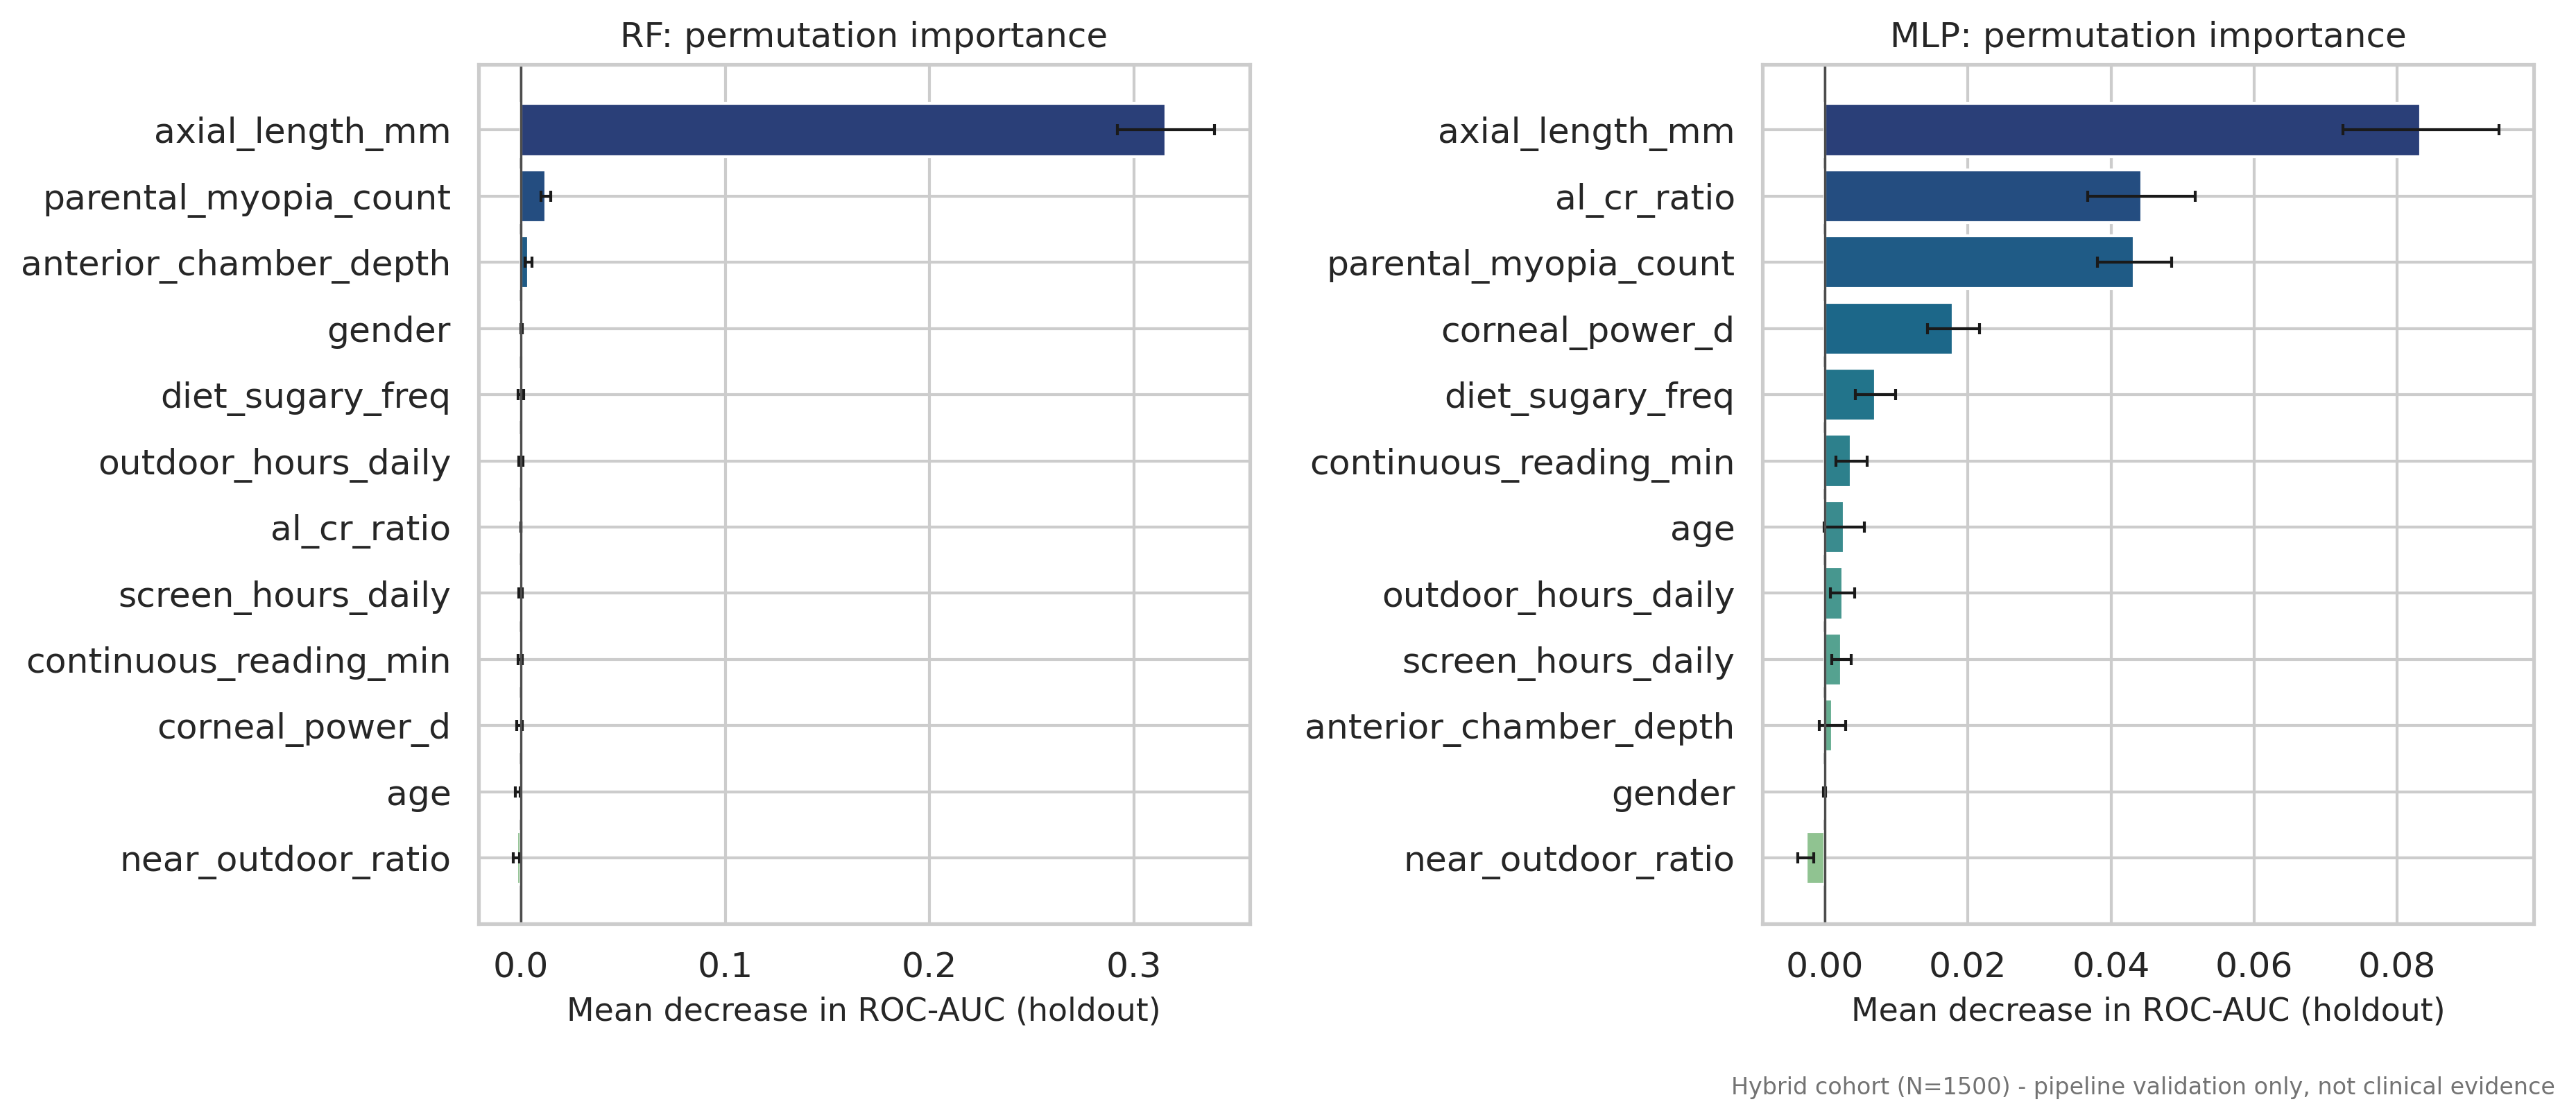

model                feature  importance_mean  importance_std
  MLP        axial_length_mm           0.0833          0.0109
  MLP            al_cr_ratio           0.0443          0.0075
  MLP  parental_myopia_count           0.0433          0.0052
  MLP        corneal_power_d           0.0180          0.0037
  MLP       diet_sugary_freq           0.0071          0.0028
  MLP continuous_reading_min           0.0037          0.0022
  MLP                    age           0.0027          0.0028
  MLP    outdoor_hours_daily           0.0025          0.0017
  MLP     screen_hours_daily           0.0023          0.0013
  MLP anterior_chamber_depth           0.0010          0.0018
  MLP                 gender          -0.0000          0.0001
  MLP     near_outdoor_ratio          -0.0027          0.0011
   RF        axial_length_mm           0.3157          0.0238
   RF  parental_myopia_count           0.0123          0.0023
   RF anterior_chamber_depth           0.0037          0.0017
   RF   

In [5]:
from sklearn.inspection import permutation_importance

perm_rows = []
for name in dict.fromkeys(["RF", BEST_EXTENDED]):
    try:
        r = permutation_importance(models[name], X_te, y_te, scoring="roc_auc", n_repeats=CONFIG["PERM_N_REPEATS"],
                                   random_state=SEED, n_jobs=1)
    except Exception as exc:
        raise RuntimeError(f"Permutation importance failed for {name}: {exc}") from exc
    for f, m, s in zip(FEATURES, r.importances_mean, r.importances_std):
        perm_rows.append({"model": name, "feature": f, "importance_mean": m, "importance_std": s})
perm_df = pd.DataFrame(perm_rows)

panels = perm_df.model.unique()
fig, axes = plt.subplots(1, len(panels), figsize=(6.2 * len(panels), 5.2), squeeze=False)
for ax, name in zip(axes[0], panels):
    d = perm_df[perm_df.model == name].sort_values("importance_mean")
    ax.barh(d.feature, d.importance_mean, xerr=d.importance_std, color=sns.color_palette("crest", len(d)),
            error_kw={"elinewidth": 1, "capsize": 2})
    ax.axvline(0, color="0.3", lw=0.8)
    ax.set(title=f"{name}: permutation importance", xlabel="Mean decrease in ROC-AUC (holdout)")
fig.tight_layout()
fig6_paths = save_figure(fig, "fig6_importance")
show_saved("fig6_importance")
print(perm_df.sort_values(["model", "importance_mean"], ascending=[True, False]).round(4).to_string(index=False))

## 4.3 SHAP - TreeExplainer (RF / XGBoost / LightGBM) and KernelExplainer (SVM / MLP / FT-Transformer)
Tree models are explained on the pipeline's transformed features (scaled numerics, raw category codes);
kernel models are explained on the raw input features through the full pipeline. Tree SHAP values for
XGBoost/LightGBM are in log-odds units; RF and kernel explanations are in probability units.

In [ ]:
import shap

rng = np.random.default_rng(SEED)
ex_idx = rng.choice(len(X_te), size=min(CONFIG["SHAP_N_EXPLAIN"], len(X_te)), replace=False)
X_ex_raw = X_te.iloc[np.sort(ex_idx)]
X_bg_raw = X_tr.sample(n=min(CONFIG["SHAP_BACKGROUND"], len(X_tr)), random_state=SEED)


def _positive_class(values: Any, base: Any) -> Tuple[np.ndarray, float]:
    """Normalise SHAP outputs (list / 3-D / 2-D) to the positive class."""
    if isinstance(values, list):
        values = values[1]
    values = np.asarray(values)
    if values.ndim == 3:
        values = values[:, :, 1]
    base = np.asarray(base).ravel()
    return values, float(base[1] if base.size > 1 else base[0])


def explain_model(name: str, pipe: Any, kind: str) -> Dict[str, Any]:
    """Return SHAP values, base value, feature frame and explainer type for one fitted pipeline."""
    if kind == "tree":
        transformer = pipe[:-1]
        names = list(transformer.get_feature_names_out())
        Xt = pd.DataFrame(transformer.transform(X_ex_raw), columns=names, index=X_ex_raw.index)
        explainer = shap.TreeExplainer(pipe[-1])
        vals, base = _positive_class(explainer.shap_values(Xt.values), explainer.expected_value)
        return {"values": vals, "base": base, "X": Xt, "explainer": "TreeExplainer"}
    predict = lambda A: pipe.predict_proba(pd.DataFrame(A, columns=FEATURES))[:, 1]
    explainer = shap.KernelExplainer(predict, X_bg_raw.values)
    vals = explainer.shap_values(X_ex_raw.values, nsamples=CONFIG["SHAP_KERNEL_NSAMPLES"], silent=True)
    vals, base = _positive_class(vals, explainer.expected_value)
    return {"values": vals, "base": base, "X": X_ex_raw.copy(), "explainer": "KernelExplainer"}


SHAP_TARGETS = [m for m in ["RF", "XGBoost", "LightGBM", "SVM", "MLP", "FT-Transformer"] if m in models]
for extra in (BEST_OVERALL, BEST_EXTENDED):
    if extra not in SHAP_TARGETS:
        SHAP_TARGETS.append(extra)
shap_results: Dict[str, Dict[str, Any]] = {}
for name in SHAP_TARGETS:
    kind = BMETA["models"][name]["kind"]
    if kind == "tree" and not hasattr(models[name].named_steps["model"], "feature_importances_"):
        kind = "kernel"  # e.g. sklearn MLP fallback registered under a tree name
    t0 = time.time()
    try:
        shap_results[name] = explain_model(name, models[name], kind)
    except Exception as exc:
        log(STEP, f"SHAP failed for {name}: {type(exc).__name__}: {exc} (continuing with other models)")
        continue
    log(STEP, f"SHAP {name:<22} {shap_results[name]['explainer']:<15} {time.time() - t0:.1f}s")

mean_abs = pd.DataFrame({n: pd.Series(np.abs(r["values"]).mean(0), index=r["X"].columns) for n, r in shap_results.items()})
mean_abs = mean_abs.reindex(FEATURES)
print(mean_abs.round(4).to_string())

SHAP RF                     TreeExplainer   1.4s
SHAP XGBoost                TreeExplainer   0.1s
SHAP LightGBM               TreeExplainer   0.1s


/usr/local/lib/python3.13/dist-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


SHAP SVM                    KernelExplainer 89.3s
SHAP MLP                    KernelExplainer 5.2s
SHAP FT-Transformer         KernelExplainer 199.3s
SHAP LR                     KernelExplainer 6.0s
                            RF  XGBoost  LightGBM     SVM     MLP  FT-Transformer      LR
age                     0.0199   0.1373    0.1586  0.0115  0.0409          0.0271  0.0143
screen_hours_daily      0.0182   0.2461    0.2960  0.0110  0.0245          0.0186  0.0134
continuous_reading_min  0.0124   0.3602    0.3831  0.0138  0.0287          0.0275  0.0189
outdoor_hours_daily     0.0105   0.1525    0.1670  0.0166  0.0229          0.0049  0.0176
axial_length_mm         0.3054   3.2745    3.8290  0.2924  0.1091          0.2435  0.3219
corneal_power_d         0.0195   0.0754    0.1696  0.0124  0.0674          0.0489  0.0062
anterior_chamber_depth  0.0392   0.2501    0.3637  0.0153  0.0382          0.0142  0.0046
al_cr_ratio                NaN      NaN       NaN  0.0007  0.0700          0.0545

## 4.4 Figure 7 - SHAP beeswarm, bar summary and top-6 waterfall (best available model)

Saved figure: figures/fig7_shap_summary.png + .svg


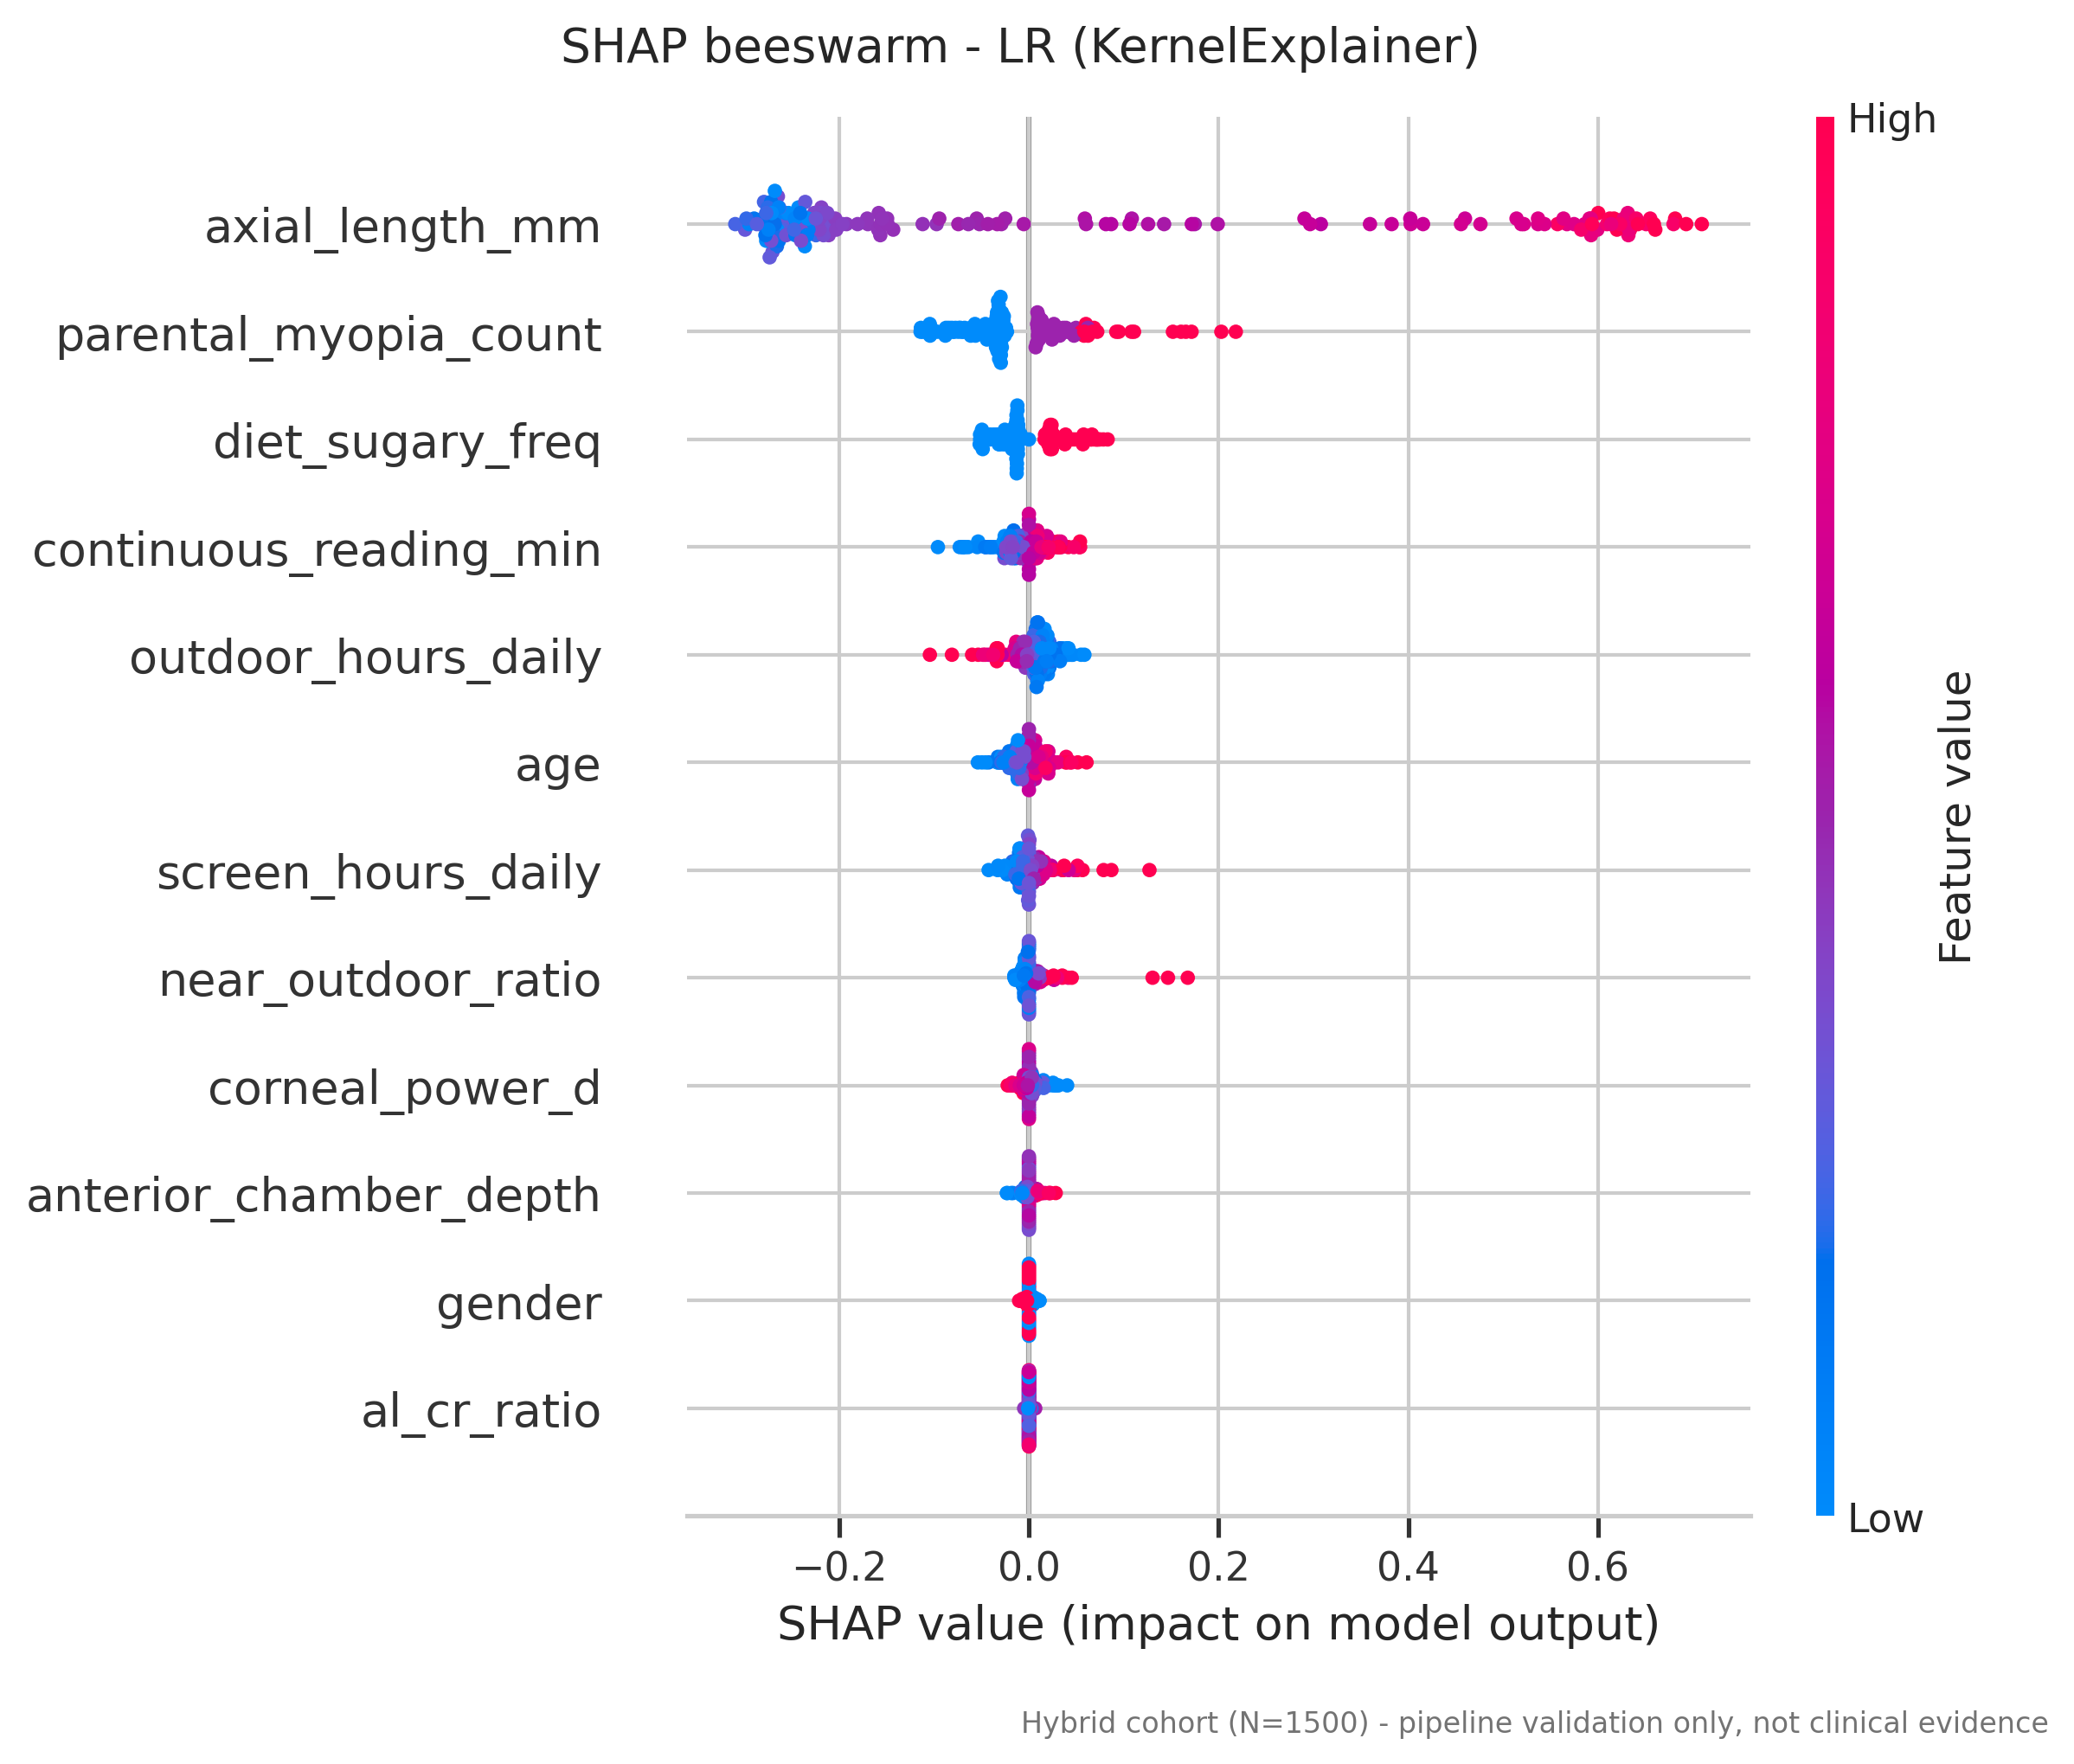

Saved figure: figures/fig7_shap_bar.png + .svg
Saved figure: figures/fig7_shap_waterfall.png + .svg


In [ ]:
PRIMARY = next((m for m in cv_auc.index if m in shap_results), None)
if PRIMARY is None:
    raise RuntimeError("No SHAP results were produced - see the log messages above.")
R = shap_results[PRIMARY]
fig7_paths: List[Path] = []

plt.figure()
shap.summary_plot(R["values"], R["X"], show=False, max_display=len(R["X"].columns))
fig = plt.gcf()
fig.suptitle(f"SHAP beeswarm - {PRIMARY} ({R['explainer']})", y=1.02)
fig7_paths += save_figure(fig, "fig7_shap_summary")
show_saved("fig7_shap_summary")

plt.figure()
shap.summary_plot(R["values"], R["X"], plot_type="bar", show=False, max_display=len(R["X"].columns))
fig = plt.gcf()
fig.suptitle(f"Mean |SHAP| - {PRIMARY}", y=1.02)
fig7_paths += save_figure(fig, "fig7_shap_bar")

p_ex = models[PRIMARY].predict_proba(X_ex_raw)[:, 1]
i_star = int(np.argmax(p_ex))  # highest-risk explained child
expl = shap.Explanation(values=R["values"][i_star], base_values=R["base"], data=R["X"].iloc[i_star].values,
                        feature_names=list(R["X"].columns))
plt.figure()
shap.plots.waterfall(expl, max_display=7, show=False)  # top 6 features + 'other features'
fig = plt.gcf()
fig.suptitle(f"Top-6 SHAP waterfall - {PRIMARY}, test child row_id={int(test_df.row_id.iloc[np.sort(ex_idx)[i_star]])}, "
             f"p(myopia)={p_ex[i_star]:.2f}", y=1.02, fontsize=11)
fig7_paths += save_figure(fig, "fig7_shap_waterfall")

## 4.5 Figure 3 - multivariable logistic regression odds ratios (statsmodels)
Features = those kept by the LASSO selector of the fitted LR pipeline. Continuous features are
standardised on the training split, so their OR is **per 1 SD**; binary/ordinal ORs are per unit.

Method: statsmodels Logit (MLE, Wald 95% CI) | selected features: 11/12
               feature   coef      OR  ci_low  ci_high  p_value    scale                               method
                   age  0.239   1.270   0.934    1.727    0.128 per 1 SD statsmodels Logit (MLE, Wald 95% CI)
    screen_hours_daily  0.395   1.484   1.045    2.106    0.027 per 1 SD statsmodels Logit (MLE, Wald 95% CI)
continuous_reading_min  0.318   1.375   1.022    1.850    0.036 per 1 SD statsmodels Logit (MLE, Wald 95% CI)
   outdoor_hours_daily -0.516   0.597   0.402    0.887    0.011 per 1 SD statsmodels Logit (MLE, Wald 95% CI)
       axial_length_mm  5.374 215.663  88.942  522.932    0.000 per 1 SD statsmodels Logit (MLE, Wald 95% CI)
       corneal_power_d -0.136   0.873   0.661    1.152    0.336 per 1 SD statsmodels Logit (MLE, Wald 95% CI)
anterior_chamber_depth  0.011   1.011   0.754    1.356    0.941 per 1 SD statsmodels Logit (MLE, Wald 95% CI)
    near_outdoor_ratio  0.106   1.112   0.739   

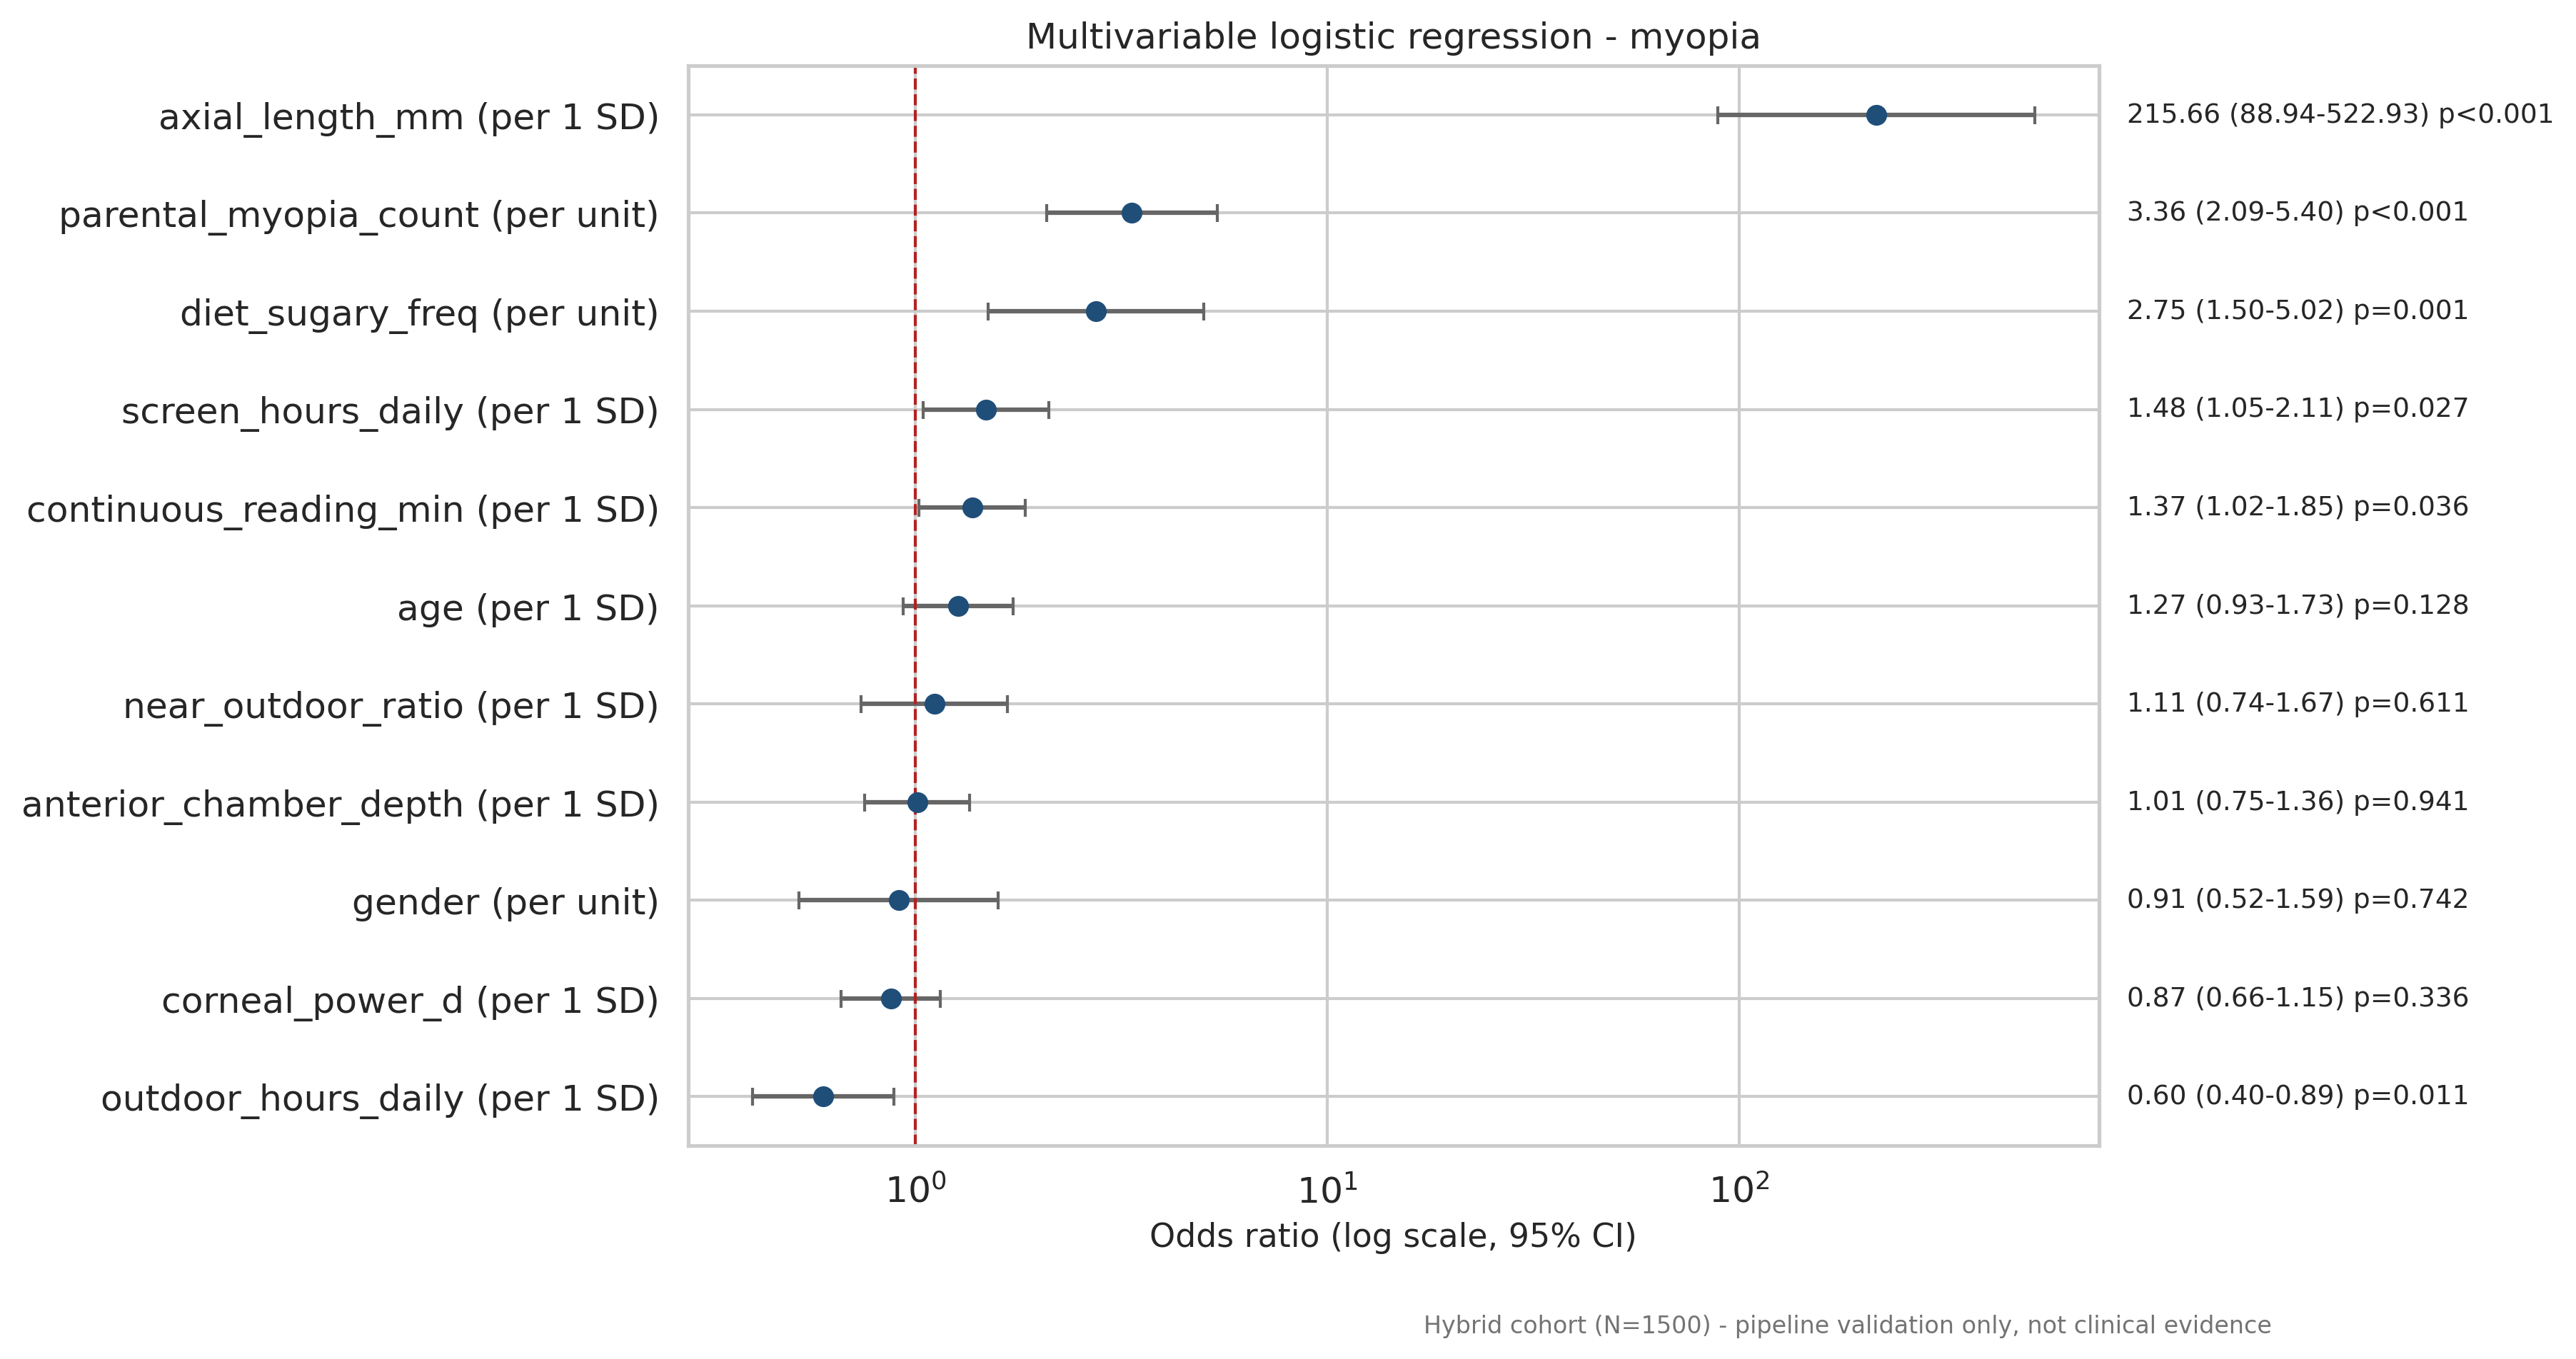

In [ ]:
import statsmodels.api as sm

lr_pipe = models["LR"]
if "select" in lr_pipe.named_steps:
    support = lr_pipe.named_steps["select"].get_support()
    selected = [f for f, keep in zip(lr_pipe.named_steps["prep"].get_feature_names_out(), support) if keep]
else:
    selected = FEATURES
Xo = X_tr[selected].copy()
num_sel = [c for c in selected if c in FSPEC["numeric"]]
Xo[num_sel] = (Xo[num_sel] - Xo[num_sel].mean()) / Xo[num_sel].std(ddof=0)
Xo = sm.add_constant(Xo, has_constant="add")

OR_METHOD = "statsmodels Logit (MLE, Wald 95% CI)"
separation = False
try:
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter("always")
        res = sm.Logit(y_tr, Xo).fit(disp=0, maxiter=200)
    separation = any("separation" in str(w.message).lower() for w in caught)
    separation |= not res.mle_retvals.get("converged", True) or bool((res.bse.abs() > 50).any())
    or_df = pd.DataFrame({"feature": res.params.index, "coef": res.params.values, "OR": np.exp(res.params.values),
                          "ci_low": np.exp(res.conf_int()[0].values), "ci_high": np.exp(res.conf_int()[1].values),
                          "p_value": res.pvalues.values})
except Exception as exc:
    if "separation" not in str(exc).lower():
        raise RuntimeError(f"statsmodels Logit failed unexpectedly: {exc}") from exc
    separation = True
if separation:
    OR_METHOD = "penalised LR (L2, C=0.5; Firth-style fallback) with 1000-draw bootstrap 95% CI"
    log(STEP, "Separation detected -> using penalised logistic regression for odds ratios.")
    Xs = Xo.drop(columns="const")
    base_lr = LogisticRegression(C=0.5, max_iter=2000)
    coef = base_lr.fit(Xs, y_tr).coef_[0]
    boots = []
    rng_b = np.random.default_rng(SEED)
    for _ in range(1000):
        i = rng_b.integers(0, len(y_tr), len(y_tr))
        boots.append(clone(base_lr).fit(Xs.iloc[i], y_tr[i]).coef_[0])
    boots = np.array(boots)
    or_df = pd.DataFrame({"feature": Xs.columns, "coef": coef, "OR": np.exp(coef),
                          "ci_low": np.exp(np.quantile(boots, 0.025, axis=0)),
                          "ci_high": np.exp(np.quantile(boots, 0.975, axis=0)), "p_value": np.nan})
or_df = or_df[or_df.feature != "const"].reset_index(drop=True)
or_df["scale"] = np.where(or_df.feature.isin(num_sel), "per 1 SD", "per unit")
or_df["method"] = OR_METHOD
print(f"Method: {OR_METHOD} | selected features: {len(selected)}/{len(FEATURES)}")
print(or_df.round(3).to_string(index=False))

d = or_df.sort_values("OR").reset_index(drop=True)
fig, ax = plt.subplots(figsize=(8.5, 0.45 * len(d) + 1.6))
ax.errorbar(d.OR, d.index, xerr=[d.OR - d.ci_low, d.ci_high - d.OR], fmt="o", color="#1f4e79", ecolor="0.4", capsize=3)
ax.axvline(1.0, color="firebrick", ls="--", lw=1)
ax.set_xscale("log")
ax.set_yticks(d.index, [f"{f} ({s})" for f, s in zip(d.feature, d.scale)])
for i, r in d.iterrows():
    ptxt = "" if np.isnan(r.p_value) else (" p<0.001" if r.p_value < 0.001 else f" p={r.p_value:.3f}")
    ax.annotate(f"{r.OR:.2f} ({r.ci_low:.2f}-{r.ci_high:.2f}){ptxt}", xy=(1.02, i), xycoords=("axes fraction", "data"),
                va="center", fontsize=9)
ax.set(xlabel="Odds ratio (log scale, 95% CI)", title="Multivariable logistic regression - myopia")
fig3_paths = save_figure(fig, "fig3_or_forest")
show_saved("fig3_or_forest")

## 4.6 Save to Drive

In [ ]:
out = {
    "perm": DIRS["tables"] / "table5_permutation_importance.csv",
    "shap": DIRS["tables"] / "table6_shap_mean_abs.csv",
    "or": DIRS["tables"] / "table4_odds_ratios.csv",
    "meta": DIRS["artifacts"] / "xai_meta.json",
}
perm_df.to_csv(out["perm"], index=False)
mean_abs.to_csv(out["shap"])
or_df.to_csv(out["or"], index=False)
save_json({"best_overall": BEST_OVERALL, "best_extended": BEST_EXTENDED, "shap_primary": PRIMARY,
           "shap_models": {n: r["explainer"] for n, r in shap_results.items()}, "n_explained": len(X_ex_raw),
           "n_background": len(X_bg_raw), "or_method": OR_METHOD, "or_features": selected,
           "separation_detected": bool(separation)}, out["meta"])
register_outputs(STEP, list(out.values()) + fig6_paths + fig7_paths + fig3_paths, {"shap_primary": PRIMARY})

Manifest updated: step '04_xai' -> 14 files registered.


In [ ]:
top = mean_abs[PRIMARY].sort_values(ascending=False).head(3).index.tolist()
print("=" * 70)
print(f"04 DONE | SHAP models={list(shap_results)} | primary={PRIMARY} | top features={top}")
print(f"OR method: {OR_METHOD}")
print(f"NEXT -> open {NOTEBOOKS['05_figures']} and Run all")

04 DONE | SHAP models=['RF', 'XGBoost', 'LightGBM', 'SVM', 'MLP', 'FT-Transformer', 'LR'] | primary=LR | top features=['axial_length_mm', 'parental_myopia_count', 'diet_sugary_freq']
OR method: statsmodels Logit (MLE, Wald 95% CI)
NEXT -> open SoftCom_05_Figures.ipynb and Run all
